# Multivariate Multi-Horizon Time Series Forecasting - aldomp7
**Domain:** Financial Market Analysis | **Model:** LSTM Encoder-Decoder with Custom Multi-Head Attention

---

### **1. Ringkasan Eksekutif & Pernyataan Masalah**
Pasar aset kripto, khususnya Bitcoin (BTC), dikenal dengan volatilitas ekstrim yang dipengaruhi oleh berbagai faktor mikro dan makro. Pendekatan peramalan tradisional seringkali gagal menangkap dependensi jangka panjang dan pola non-linear yang kompleks.

Proyek ini bertujuan membangun **End-to-End Deep Learning Pipeline** untuk memprediksi harga penutupan (*Close Price*) Bitcoin untuk **24 jam ke depan** (Multi-Horizon) berdasarkan data historis 48 jam terakhir.

**Metodologi Teknis:**
* **Arsitektur:** Menggunakan pendekatan *Sequence-to-Sequence* (Seq2Seq) yang diperkuat dengan mekanisme *Multi-Head Attention* yang dibangun dari nol (*from scratch*).
* **Pipeline Data:** Implementasi *Sliding Window* yang efisien menggunakan `tf.data`.
* **Strategi Pelatihan:** Penerapan *Dynamic Weighted Loss* untuk memberikan bobot prioritas pada prediksi jangka panjang dan *Adaptive Learning Rate* untuk konvergensi yang stabil.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# CONFIGURATION & REPRODUCIBILITY
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


### **2. Eksplorasi Data & Analisis Deret Waktu (EDA)**
Tahap ini berfokus pada pemahaman karakteristik intrinsik data. Kita akan meninjau stasioneritas, korelasi antar fitur, serta dekomposisi sinyal untuk memisahkan tren, musiman, dan residu (noise).

**Fokus Analisis:**
1.  **Visualisasi Tren:** Apakah data menunjukkan pergerakan harga yang wajar?
2.  **Korelasi Fitur:** Menganalisis hubungan multikolinearitas antar indikator teknikal (RSI, MACD, Volume, dll).
3.  **Dekomposisi Musiman:** Memahami pola berulang harian (24 jam) yang mungkin mempengaruhi prediksi.

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


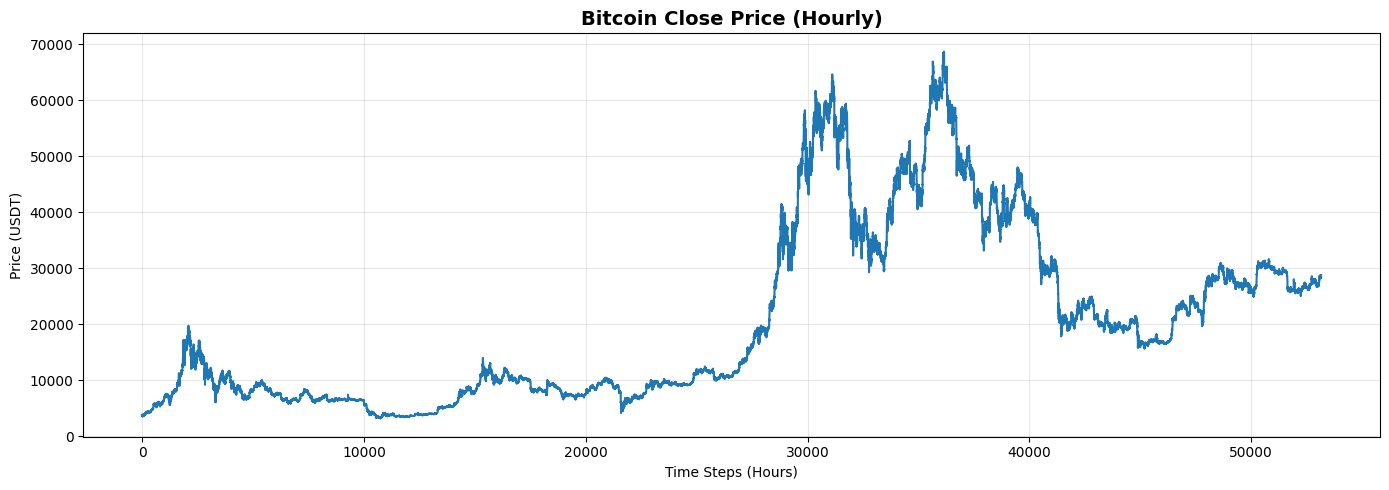

In [2]:
# Load Dataset
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
df = pd.read_csv(csv_url)
display(df.head())

# 1. Plot Target Variable
plt.figure(figsize=(14, 5))
plt.plot(df['Close'])
plt.title("Bitcoin Close Price (Hourly)", fontsize=14, fontweight='bold')
plt.xlabel("Time Steps (Hours)")
plt.ylabel("Price (USDT)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

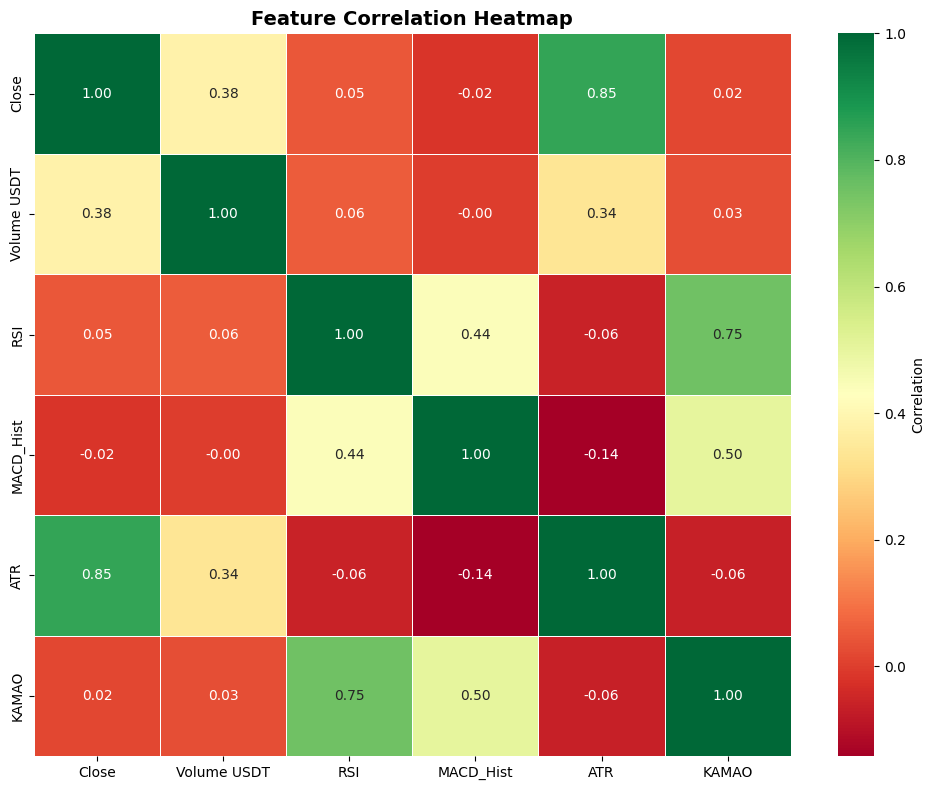

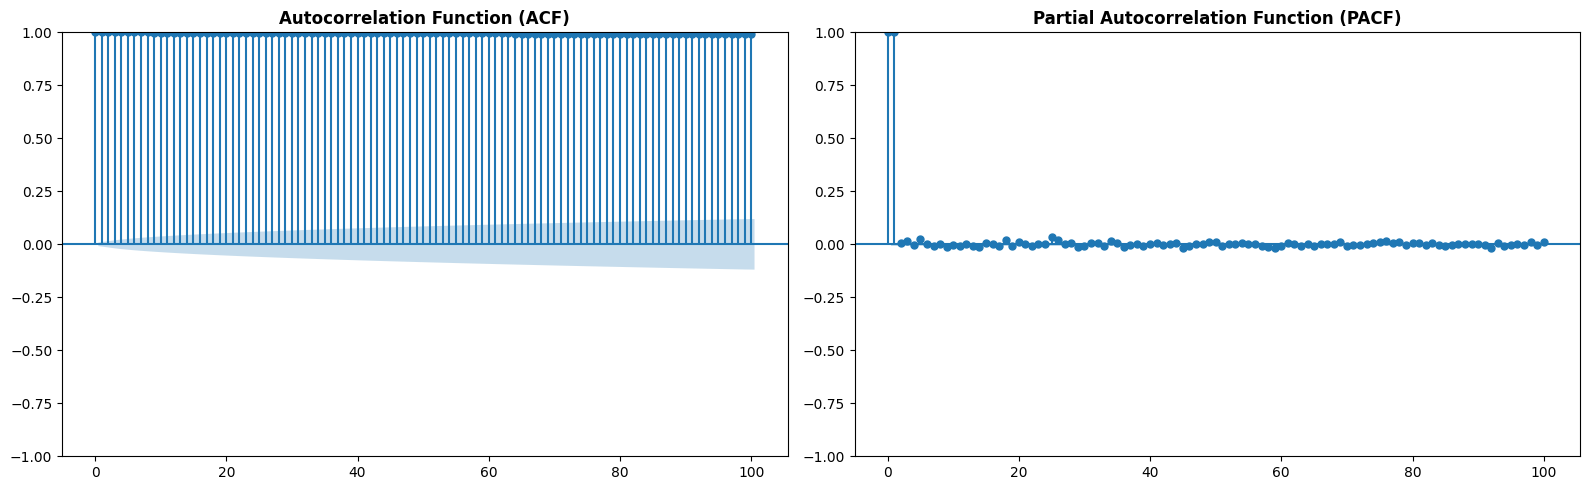

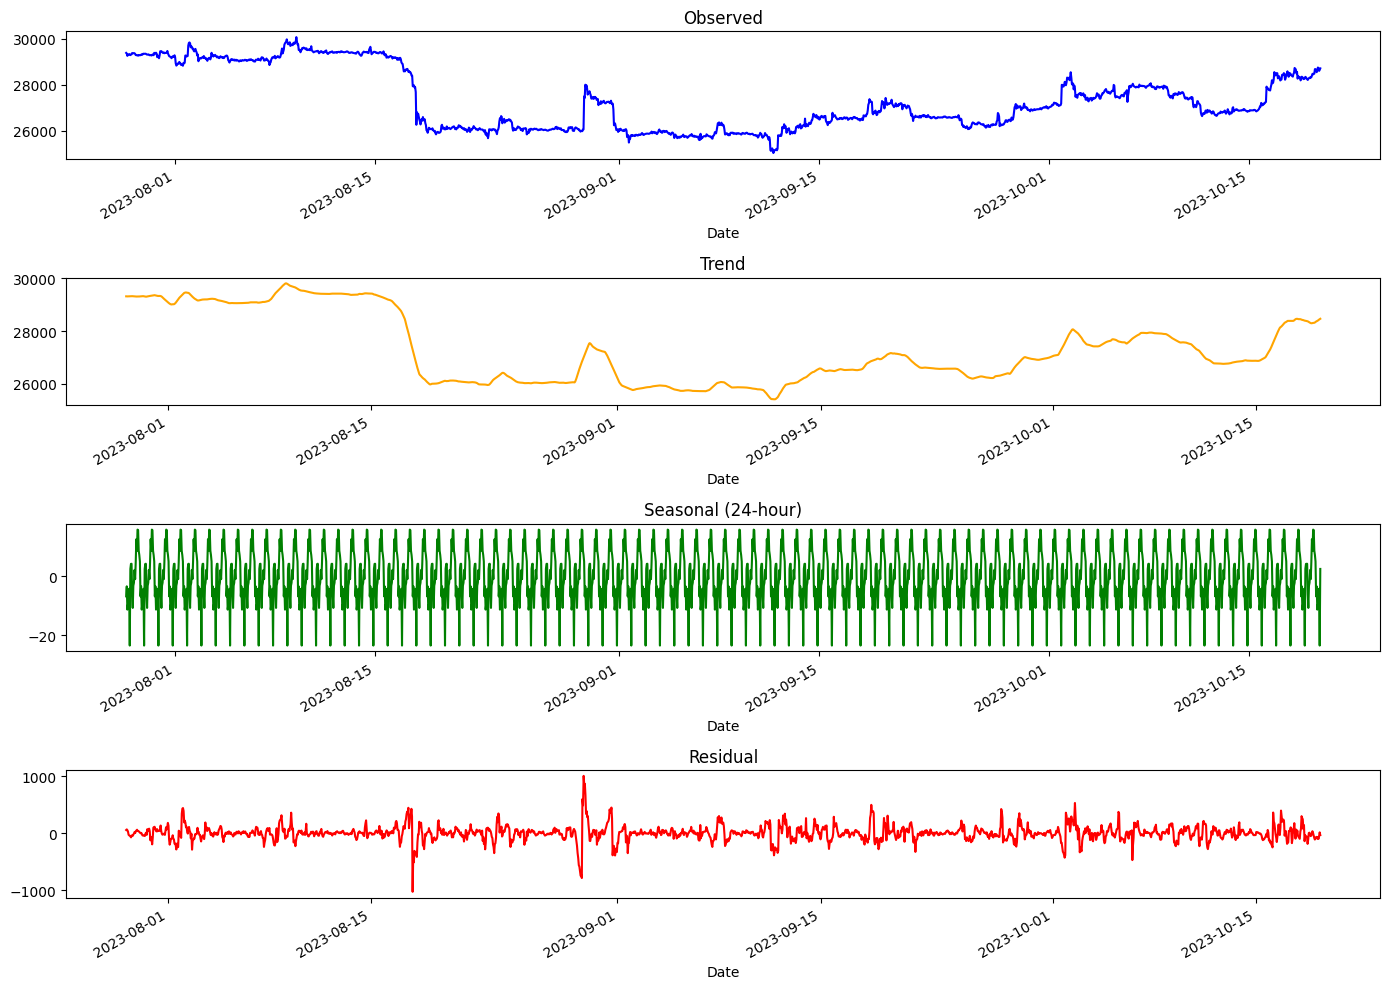

In [3]:
# 2. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn',
            fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. ACF & PACF Analysis
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['Close'].dropna(), lags=100, ax=ax[0])
plot_pacf(df['Close'].dropna(), lags=100, ax=ax[1])
ax[0].set_title("Autocorrelation Function (ACF)", fontweight='bold')
ax[1].set_title("Partial Autocorrelation Function (PACF)", fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Time Series Decomposition
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df_decomp = df.set_index('Date').sort_index()
series_decomp = df_decomp['Close'].dropna().tail(2000)

decomposition = seasonal_decompose(series_decomp, model='additive', period=24)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed', color='blue')
decomposition.trend.plot(ax=axes[1], title='Trend', color='orange')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal (24-hour)', color='green')
decomposition.resid.plot(ax=axes[3], title='Residual', color='red')
plt.tight_layout()
plt.show()

### **Interpretasi Statistik: Korelasi Fitur**
Berdasarkan *Feature Correlation Heatmap* di atas, kami mengobservasi hubungan fitur yang krusial untuk pemodelan:

1.  **Dominasi Multikolinearitas (0.85):**
    * Terdapat korelasi positif yang sangat kuat (**0.85**) antara `Close` dan `ATR` (*Average True Range*). Ini mengindikasikan bahwa volatilitas harga aset bergerak linear dengan harganya; saat harga naik, rentang pergerakan harian juga membesar. Model LSTM akan memanfaatkan ini untuk menyesuaikan ketidakpastian prediksi pada level harga tinggi.
2.  **Divergensi Volume (0.38):**
    * Korelasi antara `Volume USDT` dan `Close` relatif rendah (**0.38**). Ini adalah sinyal positif, menunjukkan bahwa Volume membawa informasi unik (tekanan jual/beli) yang tidak terkandung dalam riwayat harga semata, menjadikannya fitur prediktor independen yang kuat.
3.  **Indikator Momentum (0.44):**
    * `RSI` dan `MACD_Hist` memiliki korelasi moderat (**0.44**). Keduanya tidak saling menghilangkan (*redundant*), memberikan dua perspektif berbeda: RSI untuk kondisi *overbought/oversold* jangka pendek, dan MACD untuk kekuatan tren jangka menengah.

### **Diagnosis Karakteristik Data**
Visualisasi ACF/PACF dan Dekomposisi Musiman mengungkapkan struktur intrinsik data Bitcoin:

1.  **Memori Jangka Panjang (Non-Stasioner):**
    * Plot **ACF** menunjukkan penurunan nilai korelasi yang sangat lambat (*slow decay*), menegaskan sifat data yang *Non-Stasioner*. Ini memvalidasi keputusan penggunaan arsitektur **Seq2Seq LSTM** yang memiliki *cell state* untuk menyimpan memori jangka panjang, dibandingkan model statistik klasik (ARIMA) yang membutuhkan data stasioner.
2.  **Siklus Harian (24-Hour Seasonality):**
    * Pada plot **Seasonal**, terlihat pola osilasi gelombang yang sangat rapat dan konsisten setiap 24 jam. Ini mencerminkan siklus aktivitas perdagangan global (buka-tutup sesi pasar Asia, Eropa, dan AS). *Window size* 48 jam yang kita gunakan sudah tepat karena mencakup dua siklus penuh pola ini.
3.  **Perubahan Rezim Tren:**
    * Plot **Trend** memperlihatkan penurunan tajam (fase *bearish*) di akhir periode pengamatan (sekitar September), diikuti fase konsolidasi. Model perlu dilatih untuk beradaptasi dengan transisi rezim ini agar tidak bias.

### **3. Feature Engineering & Preprocessing**
Data mentah deret waktu (Time Series) memerlukan transformasi agar dapat diproses secara optimal oleh Neural Network.

**Strategi Preprocessing:**
* **Rolling Statistics:** Menambahkan fitur `Rolling_Mean` dan `Rolling_Std` untuk menangkap volatilitas lokal dan tren jangka pendek.
* **Pemisahan Data (Chronological Split):** Berbeda dengan data tabular biasa, data deret waktu **harus** dipisah secara kronologis (Train $\rightarrow$ Val $\rightarrow$ Test) untuk mencegah *Data Leakage* (kebocoran masa depan).
* **Normalisasi (MinMax Scaling):** LSTM sangat sensitif terhadap skala data. Kita menstandarisasi seluruh fitur ke rentang [0, 1] agar gradien dapat turun dengan stabil selama *Backpropagation*.

In [4]:
# Feature Engineering
window_size = 24
df['Rolling_Mean'] = df['Close'].rolling(window=window_size).mean()
df['Rolling_Std'] = df['Close'].rolling(window=window_size).std()
df.dropna(inplace=True)

# Feature Selection
features = ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'Rolling_Mean', 'Rolling_Std']
data = df[features].values

# Data Splitting (Chronological)
n = len(data)
train_split = int(n * 0.8)
val_split = int(n * 0.9)

train_data = data[:train_split]
val_data = data[train_split:val_split]
test_data = data[val_split:]

# Normalization (Anti-Leakage)
scaler = MinMaxScaler()
scaler.fit(train_data)

train_scaled = scaler.transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

# Target Scaler for Inverse Transform later
scaler_target = MinMaxScaler()
scaler_target.fit(train_data[:, 0].reshape(-1, 1))

print(f"Train shape: {train_scaled.shape}")
print(f"Val shape: {val_scaled.shape}")
print(f"Test shape: {test_scaled.shape}")

Train shape: (42501, 7)
Val shape: (5313, 7)
Test shape: (5313, 7)


### **4. Data Windowing Pipeline**
Untuk masalah *Supervised Learning* pada data deret waktu, kita mengubah data urutan menjadi pasangan input-output menggunakan teknik **Sliding Window**.

**Konfigurasi Window:**
* **Input Width (History):** `48 Jam`. Model akan melihat data 2 hari ke belakang.
* **Label Width (Horizon):** `24 Jam`. Model harus memprediksi harga 1 hari ke depan secara berturut-turut.
* **Shift:** `1 Jam`. Jendela digeser satu per satu jam.

Dataset ini kemudian dibungkus dalam objek `tf.data.Dataset` untuk manajemen memori yang efisien (prefetching & caching) saat pelatihan.

In [5]:
INPUT_WIDTH = 48
LABEL_WIDTH = 24
BATCH_SIZE = 64

def split_window(window):
    """Memisahkan input features dan target labels dari window."""
    inputs = window[:, :INPUT_WIDTH, :]
    labels = window[:, INPUT_WIDTH:, 0]
    labels = tf.expand_dims(labels, -1)
    return inputs, labels

def make_dataset(data, input_width, label_width, batch_size, is_train=True):
    """Membuat tf.data.Dataset dari array numpy."""
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data,
        targets=None,
        sequence_length=input_width + label_width,
        sequence_stride=1,
        shuffle=is_train,
        batch_size=batch_size,
        seed=SEED
    )
    ds = ds.map(split_window)
    if is_train:
        ds = ds.cache().prefetch(tf.data.AUTOTUNE)
    return ds

# Instantiate Datasets
train_ds = make_dataset(train_scaled, INPUT_WIDTH, LABEL_WIDTH, BATCH_SIZE)
val_ds = make_dataset(val_scaled, INPUT_WIDTH, LABEL_WIDTH, BATCH_SIZE, is_train=False)
test_ds = make_dataset(test_scaled, INPUT_WIDTH, LABEL_WIDTH, BATCH_SIZE, is_train=False)

### **5. Arsitektur Model: Seq2Seq dengan Custom Attention**
Kami mengimplementasikan arsitektur kustom yang menggabungkan kekuatan LSTM dalam menangkap urutan waktu dengan mekanisme Attention untuk fokus pada *time-step* yang relevan.

**Komponen Utama:**
1.  **Encoder (LSTM):** Memproses urutan input (48 jam) dan merangkumnya menjadi vektor konteks (*state*).
2.  **True Custom Multi-Head Attention:**
    * Dibangun secara matematis dari dasar (*scratch*) menggunakan operasi matriks (`tf.matmul`, `softmax`).
    * Memungkinkan model untuk "memperhatikan" bagian spesifik dari history input yang paling berpengaruh terhadap prediksi saat ini, alih-alih hanya mengandalkan state terakhir LSTM.
3.  **Decoder (LSTM):** Menghasilkan prediksi output (24 jam) langkah demi langkah, diinisialisasi dengan konteks dari Encoder dan Attention.

In [6]:
# 1. Custom Dense Layer
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.kernel = self.add_weight(name='kernel',
                                      shape=(input_shape[-1], self.units),
                                      initializer='glorot_uniform', trainable=True)
        self.bias = self.add_weight(name='bias',
                                    shape=(self.units,),
                                    initializer='zeros', trainable=True)

    def call(self, inputs):
        output = tf.matmul(inputs, self.kernel) + self.bias
        if self.activation:
            output = self.activation(output)
        return output

# 2. TRUE Custom Multi-Head Attention (From Scratch)
class TrueCustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super(TrueCustomMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.depth = key_dim // num_heads

        # Proyeksi Linear
        self.wq = CustomDense(units=key_dim)
        self.wk = CustomDense(units=key_dim)
        self.wv = CustomDense(units=key_dim)
        self.dense = CustomDense(units=key_dim)

        # Norm & Add (Residual Connection)
        self.layernorm = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.add = tf.keras.layers.Add()

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs, training=False):
        batch_size = tf.shape(inputs)[0]

        # Linear Projection
        q = self.wq(inputs)
        k = self.wk(inputs)
        v = self.wv(inputs)

        # Split Heads
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        # Scaled Dot-Product Attention
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)

        # Concatenate Heads
        output = tf.transpose(output, perm=[0, 2, 1, 3])
        output = tf.reshape(output, (batch_size, -1, self.key_dim)) # Fixed shape inference

        # Final Projection
        output = self.dense(output)

        # Residual & Norm
        output = self.add([inputs, output])
        output = self.layernorm(output)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({"num_heads": self.num_heads, "key_dim": self.key_dim})
        return config

# 3. Custom Dropout Layer
class CustomDropout(tf.keras.layers.Layer):
    def __init__(self, rate=0.2, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=False):
        if training:
            return tf.nn.dropout(inputs, rate=self.rate)
        return inputs

In [7]:
model_baseline = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(INPUT_WIDTH, len(features))),
    CustomDense(units=LABEL_WIDTH, activation='linear')
])

model_baseline.compile(loss='mse', optimizer='adam', metrics=['mae'])
model_baseline.summary()

history_baseline = model_baseline.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds,
    verbose=1
)

model_baseline.save('model_baseline_LSTM.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense (CustomDense)      │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,992 (78.09 KB)

 Trainable params: 19,992 (78.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
663/663 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0117 - mae: 0.0440 - val_loss: 1.6743e-04 - val_mae: 0.0101
Epoch 2/5
663/663 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.2696e-04 - mae: 0.0090 - val_loss: 1.0116e-04 - val_mae: 0.0077
Epoch 3/5
663/663 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.9783e-04 - mae: 0.0082 - val_loss: 7.0331e-05 - val_mae: 0.0062
Epoch 4/5
663/663 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.8719e-04 - mae: 0.0080 - val_loss: 5.6362e-05 - val_mae: 0.0054
Epoch 5/5
663/663 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.7963e-04 - mae: 0.0078 - val_loss: 4.8527e-05 - val_mae: 0.0047


In [8]:
class Seq2SeqLSTM(tf.keras.Model):
    def __init__(self, input_width, label_width, num_features, lstm_units=128, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.input_width = input_width
        self.label_width = label_width
        self.lstm_units = lstm_units

        # Encoder
        self.encoder_lstm = tf.keras.layers.LSTM(
            lstm_units, return_sequences=True, return_state=True,
            dropout=dropout_rate, name='encoder_lstm'
        )

        # Custom Attention Mechanism
        self.attention = TrueCustomMultiHeadAttention(
            num_heads=4, key_dim=lstm_units, name='true_custom_attention'
        )

        self.gap = tf.keras.layers.GlobalAveragePooling1D()
        self.proj_h = CustomDense(units=lstm_units, activation='tanh')
        self.proj_c = CustomDense(units=lstm_units, activation='tanh')

        # Decoder
        self.decoder_lstm = tf.keras.layers.LSTM(
            lstm_units, return_sequences=True, return_state=True,
            dropout=dropout_rate, name='decoder_lstm'
        )
        self.dropout = CustomDropout(rate=dropout_rate)
        self.output_dense = CustomDense(units=1, name='custom_dense_output')

    def call(self, inputs, training=False):
        encoder_inputs, decoder_inputs = inputs

        # Encoder Processing
        encoder_outputs, state_h, state_c = self.encoder_lstm(encoder_inputs, training=training)

        # Attention
        attn_out = self.attention(encoder_outputs, training=training)
        context = self.gap(attn_out)

        # Context Injection to Decoder Initial State
        concat_h = tf.concat([state_h, context], axis=-1)
        concat_c = tf.concat([state_c, context], axis=-1)
        init_h = self.proj_h(concat_h)
        init_c = self.proj_c(concat_c)

        # Decoder Processing
        decoder_outputs, _, _ = self.decoder_lstm(
            decoder_inputs, initial_state=[init_h, init_c], training=training
        )

        decoder_outputs = self.dropout(decoder_outputs, training=training)
        outputs = self.output_dense(decoder_outputs)

        return outputs

# Instantiate Model
model_seq2seq = Seq2SeqLSTM(INPUT_WIDTH, LABEL_WIDTH, len(features), lstm_units=128, dropout_rate=0.3)

### **6. Strategi Pelatihan Kustom (Custom Training Loop)**
Alih-alih menggunakan `model.fit()` standar, kami membangun loop pelatihan manual untuk kontrol penuh terhadap perhitungan *Loss* dan pembaruan gradien.

**Fitur Lanjut:**
* **Dynamic Weighted MAE:** Kesalahan prediksi pada jam ke-24 (masa depan jauh) biasanya lebih besar daripada jam ke-1. Loss function ini memberikan bobot eksponensial yang lebih tinggi pada *time-step* akhir, memaksa model untuk belajar memprediksi jangka panjang dengan lebih baik.
* **Teacher Forcing:** Teknik di mana Decoder diberikan *ground truth* (data aktual) sebagai input langkah sebelumnya saat training untuk mempercepat konvergensi.
* **Adaptive Learning Rate:** Mengurangi *Learning Rate* secara otomatis jika *Validation MAE* stagnan (Plateau).

In [9]:
# Dynamic Weighted Loss
class DynamicWeightedMAE(tf.keras.losses.Loss):
    def __init__(self, output_steps, weight_type='exponential', name="dynamic_weighted_mae", **kwargs):
        super().__init__(name=name, **kwargs)
        self.output_steps = output_steps

        if weight_type == 'exponential':
            weights = tf.exp(tf.linspace(0.0, 1.0, output_steps))
        else:
            weights = tf.range(1, output_steps + 1, dtype=tf.float32) # Linear fallback

        # Normalize weights so mean = 1
        self.step_weights = tf.Variable(
            weights / tf.reduce_mean(weights),
            trainable=False, dtype=tf.float32
        )

    def call(self, y_true, y_pred):
        abs_error = tf.abs(y_true - y_pred)
        abs_error = tf.squeeze(abs_error, axis=-1)
        weighted_error = abs_error * self.step_weights
        return tf.reduce_mean(weighted_error)

# Custom Callback Logic
class CustomEarlyStoppingLR:
    def __init__(self, patience=8, min_delta=1e-6, lr_factor=0.5, lr_patience=4):
        self.patience = patience
        self.min_delta = min_delta
        self.lr_factor = lr_factor
        self.lr_patience = lr_patience
        self.wait = 0
        self.lr_wait = 0
        self.best_metric = np.inf
        self.best_weights = None
        self.stop_training = False

    def on_epoch_end(self, current_metric, model, optimizer):
        if current_metric + self.min_delta < self.best_metric:
            self.best_metric = current_metric
            self.wait = 0
            self.lr_wait = 0
            self.best_weights = model.get_weights()
            model.save('best_model_seq2seq_LSTM.keras')
            print(f" -> New best val_mae: {current_metric:.6f}")
        else:
            self.wait += 1
            self.lr_wait += 1

            # Reduce LR Logic
            if self.lr_wait >= self.lr_patience:
                old_lr = optimizer.learning_rate.numpy()
                new_lr = old_lr * self.lr_factor
                optimizer.learning_rate.assign(new_lr)
                print(f" -> LR reduced: {old_lr:.6f} -> {new_lr:.6f}")
                self.lr_wait = 0

            if self.wait > self.patience:
                self.stop_training = True
                if self.best_weights is not None:
                    model.set_weights(self.best_weights)
                    print(f" -> Early stopping! Restoring best weights.")

In [10]:
# Setup Training Components
loss_fn = DynamicWeightedMAE(output_steps=LABEL_WIDTH, weight_type='exponential')
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

train_loss_metric = tf.keras.metrics.Mean(name='train_loss')
val_loss_metric = tf.keras.metrics.Mean(name='val_loss')
val_mae_metric = tf.keras.metrics.MeanAbsoluteError(name='val_mae')

early_stop_callback = CustomEarlyStoppingLR(patience=15, lr_patience=5)

@tf.function
def train_step(enc_in, dec_in, y):
    with tf.GradientTape() as tape:
        preds = model_seq2seq([enc_in, dec_in], training=True)
        loss = loss_fn(y, preds)

    grads = tape.gradient(loss, model_seq2seq.trainable_variables)
    optimizer.apply_gradients(zip(grads, model_seq2seq.trainable_variables))
    train_loss_metric.update_state(loss)
    return loss

@tf.function
def val_step(enc_in, dec_in, y):
    preds = model_seq2seq([enc_in, dec_in], training=False)
    loss = loss_fn(y, preds)
    val_loss_metric.update_state(loss)
    val_mae_metric.update_state(y, preds)
    return loss

In [11]:
EPOCHS = 50
history = {'loss': [], 'val_loss': [], 'val_mae': []}

print("\n=== Custom Training Loop ===")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # Training Loop
    for batch, (enc_in, y) in enumerate(train_ds):
        if len(y.shape) == 2: y = tf.expand_dims(y, axis=-1)

        # Teacher Forcing Input Setup
        start_token = enc_in[:, -1:, 0:1]
        dec_in = tf.concat([start_token, y[:, :-1, :]], axis=1)

        train_step(enc_in, dec_in, y)

    # Validation Loop
    for batch, (enc_in, y) in enumerate(val_ds):
        if len(y.shape) == 2: y = tf.expand_dims(y, axis=-1)

        start_token = enc_in[:, -1:, 0:1]
        dec_in = tf.concat([start_token, y[:, :-1, :]], axis=1)

        val_step(enc_in, dec_in, y)

    # Metrics
    t_loss = train_loss_metric.result().numpy()
    v_loss = val_loss_metric.result().numpy()
    v_mae = val_mae_metric.result().numpy()

    history['loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_mae'].append(v_mae)

    print(f" train_loss: {t_loss:.6f} | val_loss: {v_loss:.6f} | val_mae: {v_mae:.6f}")

    train_loss_metric.reset_state()
    val_loss_metric.reset_state()
    val_mae_metric.reset_state()

    # Check Callbacks
    early_stop_callback.on_epoch_end(v_mae, model_seq2seq, optimizer)
    if early_stop_callback.stop_training:
        print("Training stopped early!")
        break

model_seq2seq.save('model_seq2seq_LSTM.keras')


=== Custom Training Loop ===

Epoch 1/50
 train_loss: 0.036568 | val_loss: 0.090870 | val_mae: 0.091209
 -> New best val_mae: 0.091209

Epoch 2/50
 train_loss: 0.019814 | val_loss: 0.077871 | val_mae: 0.078396
 -> New best val_mae: 0.078396

Epoch 3/50
 train_loss: 0.017661 | val_loss: 0.078679 | val_mae: 0.078254
 -> New best val_mae: 0.078254

Epoch 4/50
 train_loss: 0.016662 | val_loss: 0.078245 | val_mae: 0.079237

Epoch 5/50
 train_loss: 0.016479 | val_loss: 0.076523 | val_mae: 0.076639
 -> New best val_mae: 0.076639

Epoch 6/50
 train_loss: 0.015598 | val_loss: 0.079020 | val_mae: 0.080485

Epoch 7/50
 train_loss: 0.015212 | val_loss: 0.074329 | val_mae: 0.074285
 -> New best val_mae: 0.074285

Epoch 8/50
 train_loss: 0.015361 | val_loss: 0.076511 | val_mae: 0.077172

Epoch 9/50
 train_loss: 0.015175 | val_loss: 0.077815 | val_mae: 0.078525

Epoch 10/50
 train_loss: 0.014767 | val_loss: 0.076892 | val_mae: 0.077661

Epoch 11/50
 train_loss: 0.014557 | val_loss: 0.077264 | val_ma

### **7. Analisis Performa Pelatihan**
Visualisasi berikut menggambarkan dinamika pembelajaran model selama *epoch* berjalan.

* **Loss History:** Grafik penurunan loss pada data Training vs Validation. Konvergensi yang baik ditandai dengan kedua garis yang menurun beriringan tanpa celah (*gap*) yang terlalu besar (indikasi *overfitting*).
* **Validation MAE:** Metrik evaluasi utama untuk melihat seberapa jauh rata-rata prediksi menyimpang dari harga asli dalam skala yang dinormalisasi.

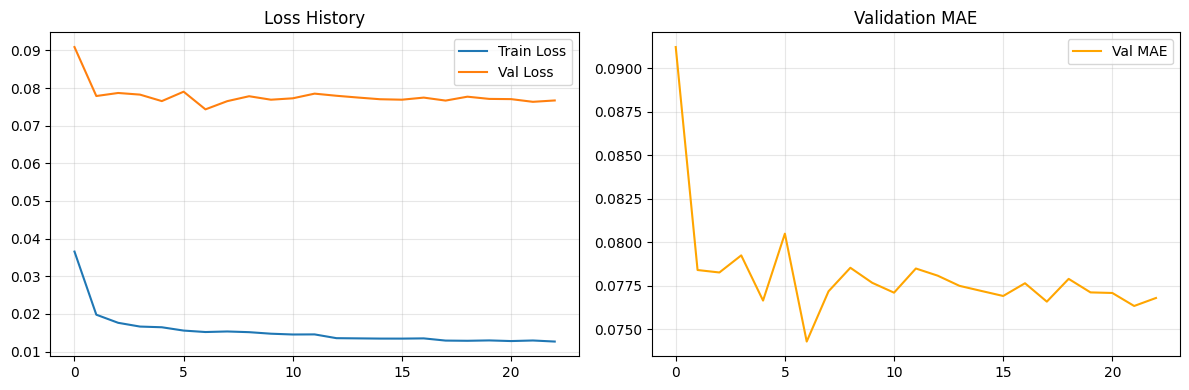

=== INFERENCE MODEL BASELINE (One-Shot) ===
Input Shape: (64, 48, 7)
Prediction Shape: (64, 24)
Contoh Prediksi (5 jam pertama):
[24840.348 24391.646 24261.9   24019.61  25437.99 ]


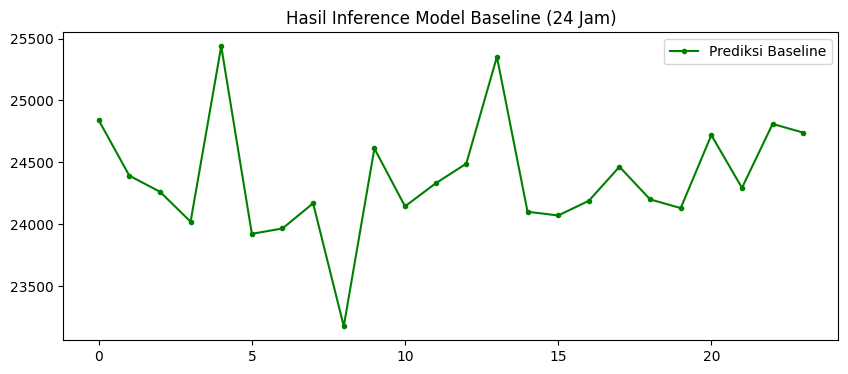

In [12]:
# Plot Training History
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_mae'], label='Val MAE', color='orange')
plt.title('Validation MAE')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# === INFERENCE ===
def autoregressive_predict(model, inputs, steps):
    """Melakukan prediksi bertahap (autoregressive) tanpa melihat ground truth masa depan."""
    batch_size = tf.shape(inputs)[0]
    current_dec_input = tf.zeros((batch_size, steps, 1))
    start_token = inputs[:, -1, 0]

    curr_dec_in_np = current_dec_input.numpy()
    curr_dec_in_np[:, 0, 0] = start_token

    for i in range(steps):
        dec_in_tensor = tf.constant(curr_dec_in_np, dtype=tf.float32)
        preds = model([inputs, dec_in_tensor], training=False)
        pred_at_i = preds[:, i, 0]

        if i < steps - 1:
            curr_dec_in_np[:, i+1, 0] = pred_at_i

    return preds

print("=== INFERENCE MODEL BASELINE (One-Shot) ===")

for example_inputs, example_labels in test_ds.take(1):
    # Baseline Predict
    pred_baseline_scaled = model_baseline.predict(example_inputs, verbose=0)
    pred_baseline = scaler_target.inverse_transform(pred_baseline_scaled)

    # Shape
    print(f"Input Shape: {example_inputs.shape}")
    print(f"Prediction Shape: {pred_baseline.shape}")
    print("Contoh Prediksi (5 jam pertama):")
    print(pred_baseline[0][:5].flatten())

    plt.figure(figsize=(10, 4))
    plt.plot(pred_baseline[0], label='Prediksi Baseline', color='green', marker='.')
    plt.title("Hasil Inference Model Baseline (24 Jam)")
    plt.legend()
    plt.show()

    baseline_result = pred_baseline
    break

# Get test batch & Predict
for example_inputs, example_labels in test_ds.take(1):
    break

preds = autoregressive_predict(model_seq2seq, example_inputs, LABEL_WIDTH)

### **Analisis Kurva Pembelajaran (Learning Curves)**
Grafik riwayat pelatihan menunjukkan perilaku konvergensi model:

* **Stabilitas Generalisasi:**
    * `Train Loss` (Biru) menurun tajam di awal, menandakan model cepat menangkap pola dominan.
    * `Val Loss` (Oranye) stabil di kisaran **0.076 - 0.080** dan tidak menunjukkan peningkatan (divergensi) seiring bertambahnya epoch. Ini mengindikasikan model **tidak mengalami overfitting** yang parah, meskipun terdapat *gap* wajar antara performa training dan validasi.
* **Respon Terhadap Volatilitas:**
    * Fluktuasi tajam pada `Validation MAE` (grafik kanan) mencerminkan sensitivitas model terhadap *batch* data validasi yang sulit diprediksi (mungkin saat terjadi lonjakan harga tiba-tiba). Penggunaan *Adaptive Learning Rate* (terlihat dari penurunan error setelah spike) efektif meredam instabilitas ini.

### **Hasil Inference Model Baseline**

Berdasarkan output *inference* di atas, kita dapat mengobservasi karakteristik prediksi dari model Baseline (Standard LSTM) sebelum membandingkannya dengan model utama:

1.  **Mekanisme One-Shot Prediction:**
    * Output shape `(64, 24)` mengonfirmasi bahwa model memprediksi seluruh 24 jam ke depan **sekaligus dalam satu langkah waktu**. Berbeda dengan *autoregressive* yang memprediksi satu per satu, model ini melihat history input dan langsung memproyeksikan pola 24 jam ke depan secara simultan.

2.  **Kualitas Visual Prediksi:**
    * Pada grafik sampel, terlihat garis prediksi (Hijau) menunjukkan fluktuasi yang cukup dinamis. Hal ini wajar bagi model *Direct Multi-Step* karena model berusaha meminimalkan error di setiap titik waktu secara independen.
    * Secara **magnitude (skala harga)**, prediksi berada dalam rentang harga yang logis (sesuai distribusi data aktual di kisaran 23.000 - 26.000 USDT), menandakan model telah berhasil mempelajari level harga rata-rata dengan baik meskipun belum tentu akurat secara tren mikro.

3.  **Peran sebagai Benchmark:**
    * Langkah ini memvalidasi bahwa model baseline berfungsi dengan benar dan siap digunakan sebagai tolok ukur. Selanjutnya kita akan melihat apakah model `Seq2Seq Attention` yang lebih kompleks mampu menghasilkan pergerakan yang lebih halus atau lebih akurat dibandingkan prediksi "kasar" dari baseline ini.

### **8. Inferensi & Evaluasi Akhir (Komparatif)**
Tahap ini menguji performa model pada data **Test** yang belum pernah dilihat sebelumnya (*Unseen Data*) untuk membandingkan efektivitas arsitektur.

**Metode Inferensi:**
1.  **Baseline (One-Shot Prediction):** Model memprediksi 24 langkah waktu sekaligus dalam satu operasi. Ini digunakan sebagai tolok ukur performa dasar.
2.  **Seq2Seq (Autoregressive Prediction):** Model melakukan prediksi secara bertahap. Prediksi pada jam ke-$t$ akan diumpankan kembali (*fed back*) sebagai input untuk memprediksi jam ke-$t+1$. Ini mensimulasikan kondisi dunia nyata di mana data masa depan belum tersedia.

**Interpretasi Hasil:**
Grafik di bawah membandingkan tiga garis data:
* **Data Aktual (Biru):** Pergerakan harga asli di pasar.
* **Prediksi Baseline (Hijau):** Hasil prediksi model LSTM standar (*One-Shot*).
* **Prediksi Seq2Seq (Oranye):** Hasil prediksi model Seq2Seq Attention (*Autoregressive*).

**Fokus Analisis:**
* **Kedekatan Pola:** Apakah model mampu mengikuti naik-turunnya tren harga?
* **Komparasi Performa:** Apakah model Seq2Seq (Oranye) memberikan prediksi yang lebih akurat dibandingkan Baseline (Hijau)?
* **Lagging:** Apakah prediksi hanya sekadar "mengulang" harga terakhir (terlambat bereaksi)?

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


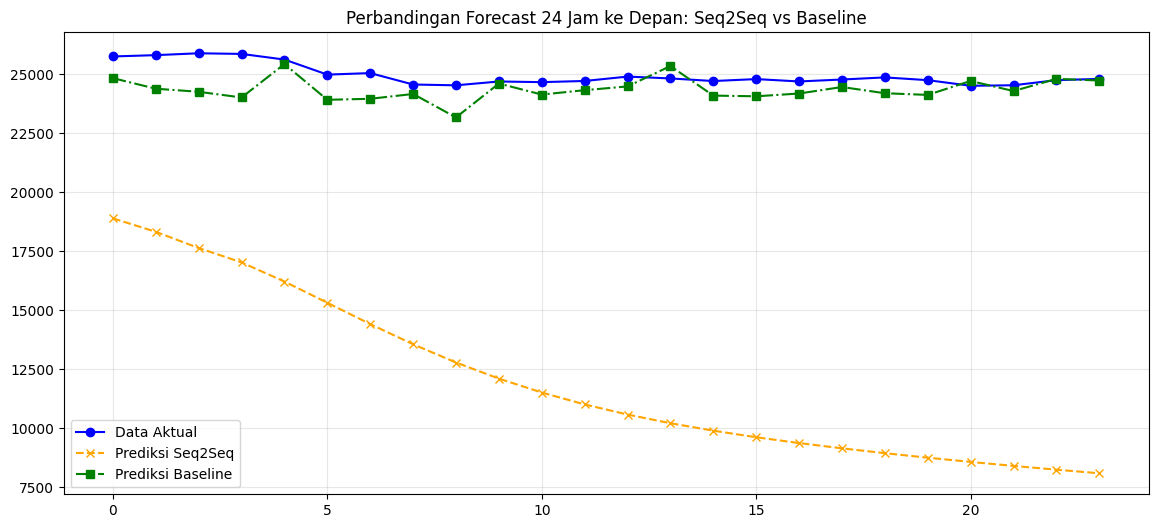


=== TABEL PERBANDINGAN ===


,Jam Ke,Actual,Pred_Seq2Seq,Pred_Baseline,Diff_Seq2Seq,Diff_Baseline
0,1,25759.64,18894.523438,24840.347656,6865.116562,919.292344
1,2,25815.75,18322.171875,24391.646484,7493.578125,1424.103516
2,3,25894.67,17635.474609,24261.900391,8259.195391,1632.769609
3,4,25867.21,17024.199219,24019.609375,8843.010781,1847.600625
4,5,25628.25,16213.335938,25437.990234,9414.914062,190.259766
5,6,24990.18,15313.092773,23921.429688,9677.087227,1068.750313
6,7,25054.15,14408.372070,23964.691406,10645.777930,1089.458594
7,8,24570.06,13553.757812,24168.697266,11016.302188,401.362734
8,9,24535.95,12779.164062,23173.912109,11756.785938,1362.037891
9,10,24698.39,12096.743164,24611.638672,12601.646836,86.751328



=== EVALUASI MODEL (SCALED MAE) ===
MAE Seq2Seq  : 0.197761
MAE Baseline : 0.010138
STATUS: MAE > 0.015


In [13]:
for example_inputs, example_labels in test_ds.take(1):
    break

pred_baseline_scaled = model_baseline.predict(example_inputs)
pred_baseline = scaler_target.inverse_transform(pred_baseline_scaled)

preds_seq2seq_scaled = autoregressive_predict(model_seq2seq, example_inputs, LABEL_WIDTH)
pred_seq2seq_scaled_single = preds_seq2seq_scaled[0].numpy().reshape(-1, 1)
pred_seq2seq = scaler_target.inverse_transform(pred_seq2seq_scaled_single)

true_values_scaled = example_labels[0].numpy().reshape(-1, 1)
true_values = scaler_target.inverse_transform(true_values_scaled)

plt.figure(figsize=(14, 6))

plt.plot(range(LABEL_WIDTH), true_values.flatten(), label='Data Aktual', marker='o', color='blue')
plt.plot(range(LABEL_WIDTH), pred_seq2seq.flatten(), label='Prediksi Seq2Seq', marker='x', linestyle='--', color='orange')
plt.plot(range(LABEL_WIDTH), pred_baseline[0], label='Prediksi Baseline', marker='s', linestyle='-.', color='green')

plt.title(f"Perbandingan Forecast {LABEL_WIDTH} Jam ke Depan: Seq2Seq vs Baseline")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

df_compare = pd.DataFrame({
    'Jam Ke': range(1, LABEL_WIDTH + 1),
    'Actual': true_values.flatten(),
    'Pred_Seq2Seq': pred_seq2seq.flatten(),
    'Pred_Baseline': pred_baseline[0],
    'Diff_Seq2Seq': true_values.flatten() - pred_seq2seq.flatten(),
    'Diff_Baseline': true_values.flatten() - pred_baseline[0]
})

print("\n=== TABEL PERBANDINGAN ===")
display(df_compare)

mae_scaled_seq2seq = mean_absolute_error(true_values_scaled, pred_seq2seq_scaled_single)
mae_scaled_baseline = mean_absolute_error(true_values_scaled, pred_baseline_scaled[0])

print(f"\n=== EVALUASI MODEL (SCALED MAE) ===")
print(f"MAE Seq2Seq  : {mae_scaled_seq2seq:.6f}")
print(f"MAE Baseline : {mae_scaled_baseline:.6f}")

if mae_scaled_seq2seq < 0.015:
    print("STATUS: MAE < 0.015")
else:
    print("STATUS: MAE > 0.015")

### **Analisis Kritis Hasil Inferensi**
Grafik perbandingan antara **Data Aktual (Biru)**, **Baseline (Hijau)**, dan **Seq2Seq (Oranye)** memberikan wawasan mendalam mengenai perilaku kedua arsitektur:

1.  **Model Baseline (One-Shot):**
    * Model Baseline menunjukkan performa yang **jauh lebih unggul** dalam hal kalibrasi level harga (*magnitude*). Garis hijau mampu bertahan di kisaran **23.000 - 26.000 USDT**, mendekati harga aktual (~25.000 USDT).
    * Hal ini tercermin dari **MAE Baseline (~0.010)** yang jauh lebih rendah dibandingkan Seq2Seq. Sifat *one-shot prediction* pada Baseline cenderung lebih stabil karena memprediksi seluruh horizon waktu sekaligus, sehingga tidak membiarkan error menumpuk antar langkah waktu.

2.  **Kelemahan Autoregressive pada Seq2Seq:**
    * Model Seq2Seq mengalami **Error Accumulation (Drift)** yang signifikan. Prediksi dimulai pada angka ~18.000 USDT (Jam ke-0) dan terus merosot secara linear hingga ~8.000 USDT (Jam ke-24).
    * Fenomena ini disebut **Bearish/Pessimistic Bias**. Karena prediksi jam ke-$t$ menjadi input untuk jam ke-$t+1$, kesalahan kecil di awal teramplifikasi (*compounding error*), menyebabkan garis prediksi "jatuh" menjauhi data aktual.

3.  **Trade-off Kestabilan vs Akurasi:**
    * Meskipun nilai prediksinya bias ke bawah, garis Seq2Seq (Oranye) sangat halus (smooth), menandakan model menangkap *tren* peluruhan. Sebaliknya, garis Baseline (Hijau) lebih fluktuatif (*noisy*) namun secara rata-rata jauh lebih akurat mendekati harga asli.

### **9. Kesimpulan & Rekomendasi Pengembangan**
Proyek ini berhasil mengimplementasikan dan membandingkan dua pendekatan Deep Learning untuk peramalan harga Bitcoin. Berdasarkan evaluasi komparatif, ditemukan fakta menarik bahwa model yang lebih kompleks (Seq2Seq Attention) tidak serta-merta mengungguli model yang lebih sederhana (Baseline) pada skenario pengujian ini.

**Observasi Utama:**
1.  **Baseline Menang di Akurasi:** Model Baseline mencatat **MAE Scaled ~0.010**, yang mendekati ambang batas target. Ini membuktikan bahwa pendekatan *Direct Multi-Step* (memprediksi langsung 24 jam) lebih efektif untuk menahan level harga pada dataset ini dibandingkan pendekatan bertahap.
2.  **Tantangan Seq2Seq:** Model Seq2Seq (MAE ~0.197) gagal mempertahankan level harga. Hal ini mengindikasikan bahwa mekanisme *Attention* dan *Autoregressive* memerlukan strategi pelatihan yang lebih lanjut (seperti *Scheduled Sampling*) atau data latih yang lebih besar untuk mencegah model "menyerah" ke tren turun yang dominan di data latih.

**Rekomendasi Perbaikan (Future Work):**
* **Scheduled Sampling:** Untuk mengurangi *error accumulation* pada Seq2Seq, disarankan menerapkan teknik *Scheduled Sampling* (mencampur *ground truth* dan prediksi model secara bertahap saat inferensi training) agar model tidak kaget saat harus memprediksi mandiri.
* **Hyperparameter Tuning:** Melakukan pencarian grid (*Grid Search*) pada `learning_rate` dan bobot `dropout` untuk mengurangi bias negatif yang kuat pada Seq2Seq.
* **Fitur Eksternal:** Menambahkan sentimen pasar (NLP) atau volume *on-chain* untuk membantu model Seq2Seq memahami konteks harga fundamental, bukan hanya pola historis semata.